<style>
    pre {
        white-space: pre-wrap;
        word-wrap: break-word;
    }
</style>

<div style="display:flex; justify-content:space-around; align-items:center; background-color:#cccccc; padding:5px; border:2px solid #333333;">
    <a href="https://estudios.upct.es/grado/5251/inicio" target="_blank">
    <img src="images/upct.png" alt="UPCT" style="height:45px; width:auto;">
    <a href="https://www.um.es/web/estudios/grados/ciencia-ingenieria-datos/" target="_blank">
    <img src="images/umu.png" alt="UMU" style="height:45px; width:auto;">
</div>

___
### **Sesión 9**
## Morfología Matemática para el Procesamiento de Imágenes

<!-- utilizar mejor el formato de cabecera "#" para que se numeren bien a la hora de generar el PDF -->
___

### Objetivos
- Comprender y aplicar las **operaciones básicas de morfología matemática** para el procesamiento de imágenes binarias.
- Utilizar **herramientas y transformaciones morfológicas más avanzadas** para una manipulación más detallada y precisa de las imágenes.    
- Desarrollar la habilidad de **ajustar y optimizar** estas técnicas en escenarios prácticos.

### Contenidos
- [Revisión de Conceptos](#conceptos10)
- [Operaciones Morfológicas Básicas](#basicas10)
- [Transformaciones Hit-or-Miss y de Sombrero de Copa](#transforma10)
- [Herramientas Adicionales de Morfología](#adicionales10)
- [Morfología Geodésica](#geodesica10)
- [Morfología en Escala de Grises](#gris10)
- [Ejercicios de práctica](#ejercicios10)

<div style="page-break-before: always;"></div>

___
<a class='anchor' id='conceptos10'></a>

## Revisión de Conceptos

### *Erosión*

<div style="display:flex; justify-content:space-around; align-items:center;">
    <img src="images/erosion.png" style="width:70%; height:auto;">
</div>
<p style="text-align: center;">Fuente: <a href="https://towardsdatascience.com/understanding-morphological-image-processing-and-its-operations-7bcf1ed11756">Understanding Morphological Image Processing and Its Operations</a></p>

### *Dilatación*
<div style="display:flex; justify-content:space-around; align-items:center;">
    <img src="images/dilatation.png" style="width:70%; height:auto;">
</div>
<p style="text-align: center;">Fuente: <a href="https://towardsdatascience.com/understanding-morphological-image-processing-and-its-operations-7bcf1ed11756">Understanding Morphological Image Processing and Its Operations</a></p>

### *Apertura y Cierre*
<div style="display:flex; justify-content:space-around; align-items:center;">
    <img src="images/close_open.png" style="width:40%; height:auto;">
</div>
<p style="text-align: center;">Fuente: <a href="https://towardsdatascience.com/understanding-morphological-image-processing-and-its-operations-7bcf1ed11756">Understanding Morphological Image Processing and Its Operations</a></p>

<br>

<div style="page-break-before: always;"></div>

___
<a class='anchor' id='basicas10'></a>

## Operaciones Morfológicas Básicas

Las operaciones de [morfología matemática](https://en.wikipedia.org/wiki/Mathematical_morphology) son esenciales para procesar y analizar imágenes binarias, permitiendo modificar estructuras y mejorar segmentaciones. Transformaciones como dilatación, erosión, apertura y cierre ayudan a eliminar ruido, conectar componentes y extraer características clave. A continuación, se muestra cómo aplicar estas operaciones utilizando el módulo de morfología de *scikit-image* y, finalmente, también se muestran su uso en *OpenCV*.

### Erosión

La [erosión](https://en.wikipedia.org/wiki/Mathematical_morphology#Erosion) es una operación morfológica básica que reduce el tamaño de los objetos, suavizando los contornos y eliminando penínsulas, protuberancias y pequeños artefactos. El siguiente ejemplo muestra cómo hacer uso de la función `binary_erosion` para realizar una erosión morfológica en una imagen binaria.

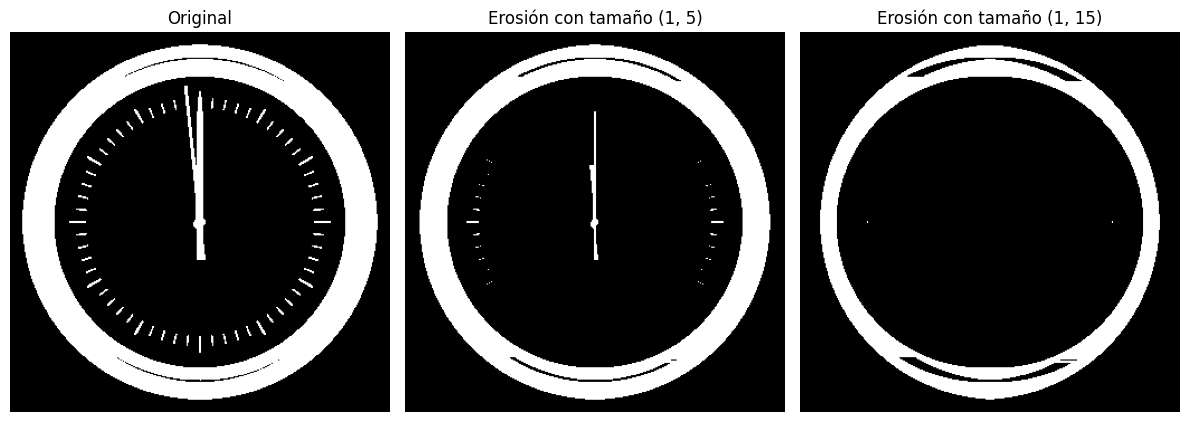

In [2]:
from skimage.io import imread
from skimage.color import rgb2gray
import matplotlib.pyplot as plt
from skimage.morphology import binary_erosion, footprint_rectangle

def plot_image(image, title='', cmap='gray', alpha=1.0):
    plt.imshow(image, cmap=cmap, alpha=alpha)
    plt.title(title, size=12)
    plt.axis('off')

# Cargar y convertir la imagen a escala de grises
image = rgb2gray(imread('images/clock2.jpg'))

# Crear una imagen binaria con un umbral fijo de 0.5
binary_image = (image > 0.5).astype(int)

# Aplicar erosión con un rectángulo de tamaño (1, 5)
eroded_image_1 = binary_erosion(binary_image, footprint_rectangle((1, 5)))

# Aplicar erosión con un rectángulo de tamaño (1, 15)
eroded_image_2 = binary_erosion(binary_image, footprint_rectangle((1, 15)))

# Mostrar las imágenes
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1); plot_image(binary_image, 'Original')
plt.subplot(1, 3, 2); plot_image(eroded_image_1, 'Erosión con tamaño (1, 5)')
plt.subplot(1, 3, 3); plot_image(eroded_image_2, 'Erosión con tamaño (1, 15)')
plt.tight_layout()
plt.show()

El resultado muestra cómo la erosión con diferentes tamaños de elementos estructurantes afecta una imagen binaria. En el primer caso, se utiliza un rectángulo delgado y pequeño, eliminando primero las marcas pequeñas del reloj. En el segundo caso, se emplea un rectángulo más amplio, lo que también erosiona las manecillas del reloj, mostrando cómo el tamaño del elemento estructurante influye en la extensión de la erosión aplicada a la imagen. A continuación, veremos cómo podemos implementar esta operación utilizando *NumPy*.

In [3]:
import numpy as np

def my_binary_erosion(image, struct_elem):

    # Obtener las dimensiones de la imagen y del elemento estructurante
    m, n = image.shape
    k, l = struct_elem.shape
    k2, l2 = k // 2, l // 2
    
    # Preparar la imagen de salida
    eroded_image = np.zeros_like(image)

    # Iterar sobre cada pixel que puede ser completamente cubierto por el elemento estructurante
    for i in range(k2, m - k2):
        for j in range(l2, n - l2):
            
            # Extraer la submatriz de la imagen del tamaño del elemento estructurante
            submat = image[i - k2:i + k2 + 1, j - l2:j + l2 + 1]
            
            # Aplicar la erosión (AND lógico)
            if np.all(submat[struct_elem == 1]):
                eroded_image[i, j] = 1
    
    return eroded_image

Como podemos ver, la erosión de una imagen implica reducir los objetos blancos aplicando el elemento estructurante a cada píxel de la imagen. En cada paso, si todos los píxeles bajo el elemento estructurante son blancos, el píxel central se mantiene blanco en la imagen resultante; de lo contrario, se vuelve negro.

### Dilatación

La [dilatación](https://en.wikipedia.org/wiki/Mathematical_morphology#Dilation) es otra operación morfológica básica que expande el tamaño de los objetos, para suavizar contornos así como cerrar agujeros y huecos en una imagen binaria. Esta operación es complementaria a la erosión. El siguiente código muestra un ejemplo de uso de la función `binary_dilation`.

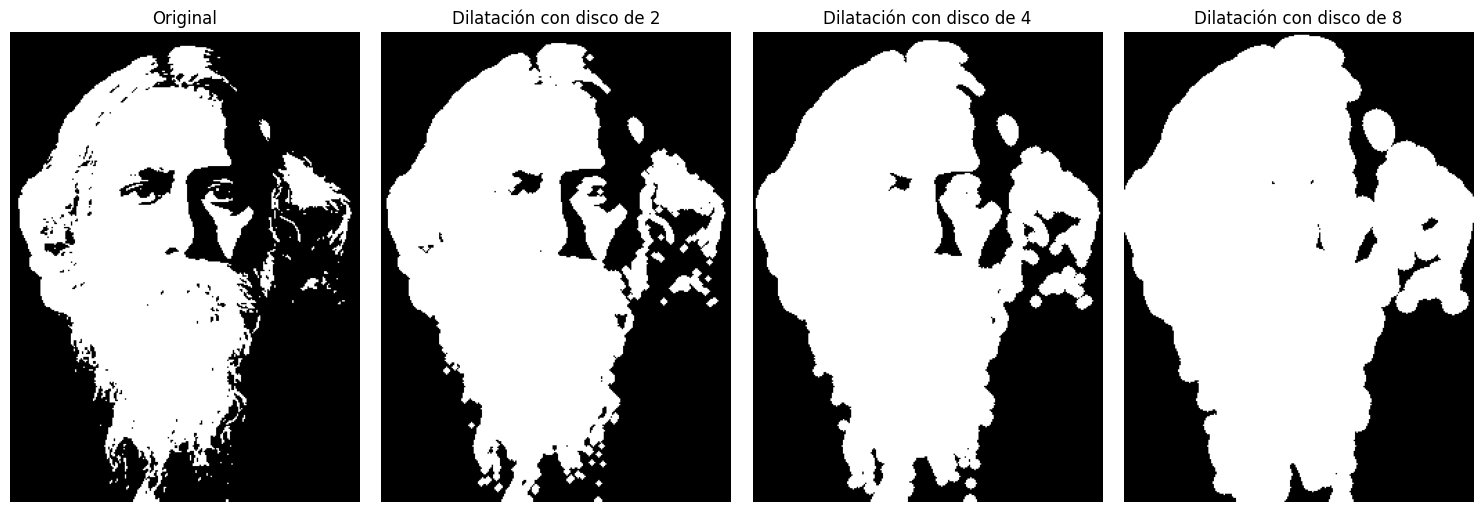

In [4]:
from skimage.morphology import binary_dilation, disk

# Cargar y procesar la imagen
image = imread('images/tagore.png', as_gray=True)
binary_image = (image > 0.5).astype(int)

# Configurar la figura
plt.figure(figsize=(15, 5))

# Mostrar la imagen original
plt.subplot(1, 4, 1)
plot_image(binary_image, 'Original')

# Aplicar dilatación con discos de diferentes tamaños y mostrar los resultados
for i, d in enumerate([2, 4, 8], start=2):
    dilated_image = binary_dilation(binary_image, disk(d))
    plt.subplot(1, 4, i)
    plot_image(dilated_image, f'Dilatación con disco de {d}')

# Mostrar las imágenes
plt.tight_layout()
plt.show()

Como se puede observar, con un disco de tamaño moderado, se eliminan pequeños huecos del rostro. Al utilizar un disco mayor, se rellenan muchos más huecos, mostrando cómo la dilatación puede suavizar y conectar diferentes partes de una imagen binaria. Veámos ahora cómo implementar esta operación en *NumPy*.

In [5]:
def my_binary_dilation(image, struct_elem):

    # Obtener las dimensiones de la imagen y del elemento estructurante
    m, n = image.shape
    k, l = struct_elem.shape
    k2, l2 = k // 2, l // 2
    
    # Preparar la imagen de salida
    dilated_image = np.zeros_like(image)

    # Iterar sobre cada pixel que puede ser completamente cubierto por el elemento estructurante
    for i in range(k2, m - k2):
        for j in range(l2, n - l2):
            
            # Extraer la submatriz de la imagen del tamaño del elemento estructurante
            submat = image[i - k2:i + k2 + 1, j - l2:j + l2 + 1]
            
            # Aplicar la dilatación (OR lógico)
            if np.any(submat[struct_elem == 1]):
                dilated_image[i, j] = 1
    
    return dilated_image

En la dilatación de una imagen, los objetos blancos se expanden aplicando el elemento estructurante a cada píxel. Si alguno de los píxeles bajo el elemento estructurante es blanco, el píxel central en la imagen resultante se establece como blanco; si no, se mantiene negro.

### Apertura y Cierre

La [apertura](https://en.wikipedia.org/wiki/Mathematical_morphology#Opening) es una operación morfológica formada por una erosión seguida de una dilatación utilizando el mismo elemento estructurante. Su finalidad es eliminar objetos pequeños y suavizar contornos, preservando en lo esencial la forma y el tamaño de las estructuras mayores de la imagen. De forma complementaria, el [cierre](https://en.wikipedia.org/wiki/Mathematical_morphology#Closing) consiste en una dilatación seguida de una erosión y se emplea para rellenar pequeños huecos, unir discontinuidades y suavizar irregularidades internas en las mismas estructuras. El siguiente bloque de código muestra cómo usar sus correspondientes funciones.

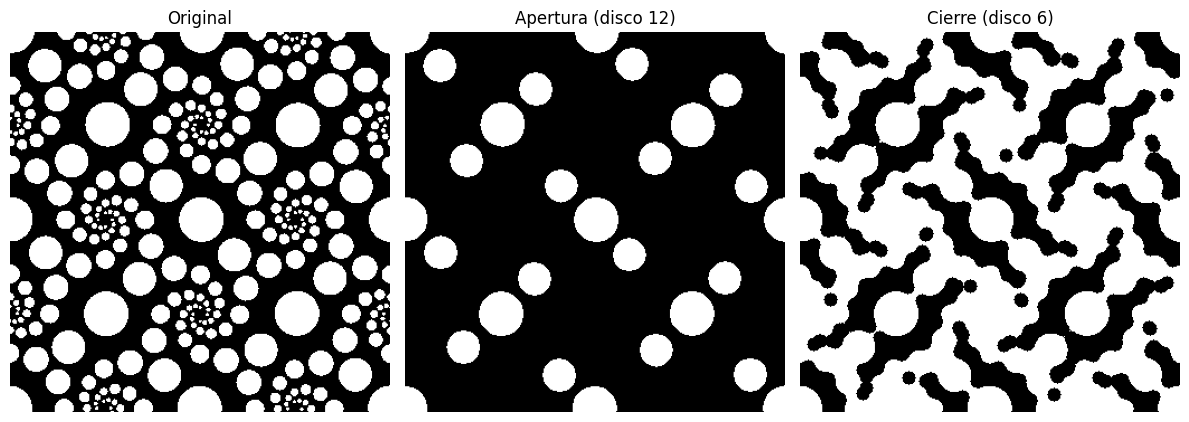

In [6]:
from skimage.morphology import binary_opening, binary_closing

# Cargar y procesar la imagen
im = rgb2gray(imread('images/circles.jpg'))
im = (im > 0.5).astype(int)

# Aplicar apertura con un disco de tamaño 12
im1 = binary_opening(im, disk(12))

# Aplicar cierre con un disco de tamaño 6
im2 = binary_closing(im, disk(6))

# Mostrar las imágenes
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1); plot_image(im, 'Original')
plt.subplot(1, 3, 2); plot_image(im1, 'Apertura (disco 12)')
plt.subplot(1, 3, 3); plot_image(im2, 'Cierre (disco 6)')
plt.tight_layout()
plt.show()

Los resultados muestran que la operación de apertura con un disco de tamaño 12 conserva solo los círculos más grandes, eliminando los pequeños detalles. La operación de cierre con un disco de tamaño 6 rellena los pequeños huecos, uniformizando la imagen en general. A continuación, veamos el efecto de intercambiar estas operaciones de apertura y cierre por operaciones básicas de erosión y dilatación.

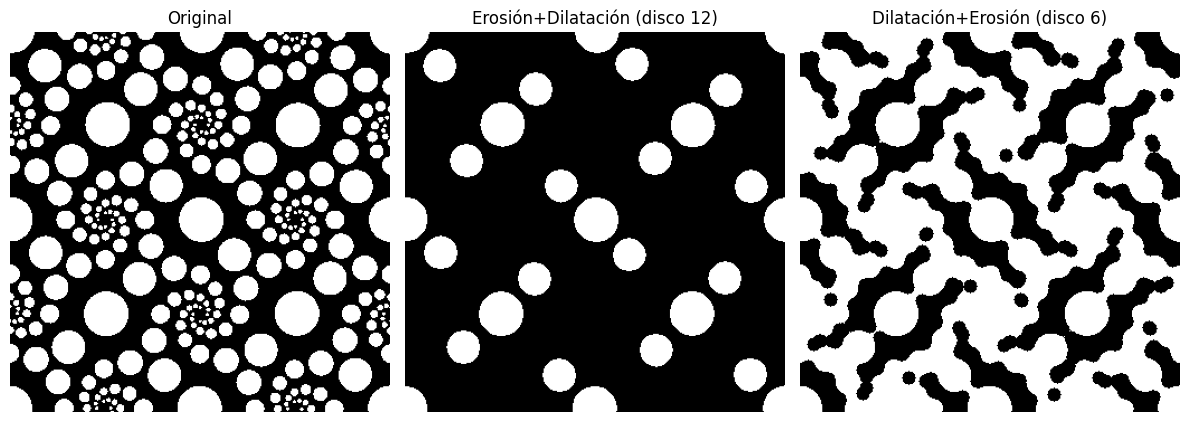

In [7]:
# Aplicar erosión+dilatación (apertura) con un disco de tamaño 12
im3 = binary_erosion(im, disk(12))
im3 = binary_dilation(im3, disk(12))

# Aplicar dilatación+erosion (cierre) con un disco de tamaño 6
im4 = binary_dilation(im, disk(6))
im4 = binary_erosion(im4, disk(6))

# Mostrar las imágenes
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1); plot_image(im, 'Original')
plt.subplot(1, 3, 2); plot_image(im3, 'Erosión+Dilatación (disco 12)')
plt.subplot(1, 3, 3); plot_image(im4, 'Dilatación+Erosión (disco 6)')
plt.tight_layout()
plt.show()

Como podemos observar, realizar manualmente una erosión seguida de una dilatación equivale a una apertura, y una dilatación seguida de una erosión equivale a un cierre. En ambos casos, el resultado es idéntico al de aplicar directamente las operaciones de apertura y cierre, siempre que se utilicen los mismos elementos estructurantes.

### Funciones de OpenCV

Todas estas operaciones también pueden ser aplicadas utilizando las funciones disponibles en la librería [*OpenCV*](https://docs.opencv.org/4.x/d9/d61/tutorial_py_morphological_ops.html). El siguiente código muestra un ejemplo de uso de cada una de estas transformaciones, utilizado un elemento estructurante rectangular de tamaño $5\times5$.

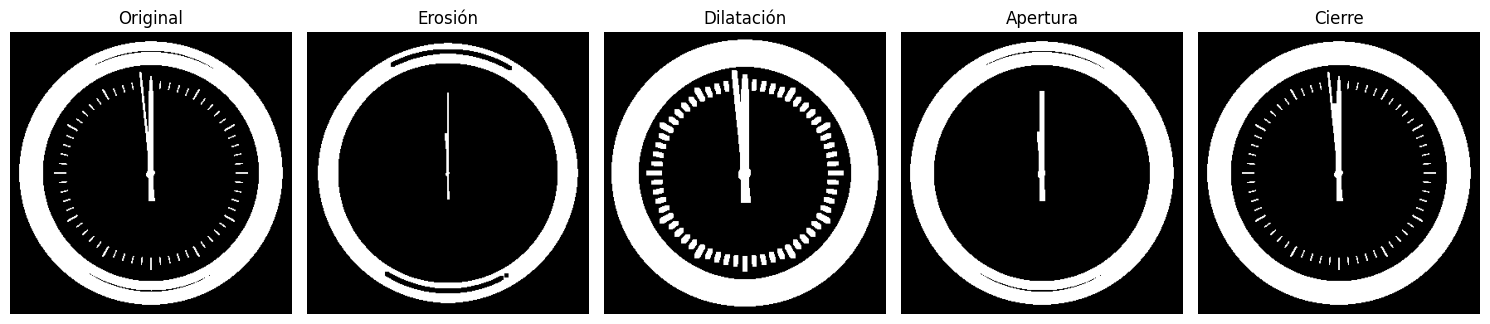

In [8]:
import cv2

# Cargar y convertir la imagen a escala de grises
image = cv2.imread('images/clock2.jpg', cv2.IMREAD_GRAYSCALE)

# Crear una imagen binaria con un umbral fijo de 0.5
_, binary_image = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)

# Definir elemento estructurante
struct_elem = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))

# Aplicar erosión, dilatación, apertura y cierre
eroded_image = cv2.erode(binary_image, struct_elem)
dilated_image = cv2.dilate(binary_image, struct_elem)
opened_image = cv2.morphologyEx(binary_image, cv2.MORPH_OPEN, struct_elem)
closed_image = cv2.morphologyEx(binary_image, cv2.MORPH_CLOSE, struct_elem)

# Mostrar las imágenes
plt.figure(figsize=(15, 5))
plt.subplot(1, 5, 1); plot_image(binary_image, 'Original')
plt.subplot(1, 5, 2); plot_image(eroded_image, 'Erosión')
plt.subplot(1, 5, 3); plot_image(dilated_image, 'Dilatación')
plt.subplot(1, 5, 4); plot_image(opened_image, 'Apertura')
plt.subplot(1, 5, 5); plot_image(closed_image, 'Cierre')
plt.tight_layout()
plt.show()

<div style="page-break-before: always;"></div>

___
<a class='anchor' id='transforma10'></a>

## Transformaciones Hit-or-Miss y de Sombrero de Copa

Tras revisar las operaciones morfológicas básicas, es posible avanzar hacia transformaciones más especializadas que permiten detectar estructuras concretas y resaltar detalles sutiles dentro de una imagen. Entre ellas destacan las transformaciones de localización (hit-or-miss) y de sombrero de copa, que amplían la capacidad de análisis morfológico al facilitar la localización de patrones específicos y la extracción de elementos pequeños que pueden pasar desapercibidos con técnicas más simples. A continuación se describen en detalle cada una de estas transformaciones.

### Transformación de Localización

La transformación de localización ([hit-or-miss](https://en.wikipedia.org/wiki/Hit-or-miss_transform)) es una operación morfológica utilizada para identificar patrones en una imagen binaria. Se realiza en dos pasos: primero, se aplica una erosión a la imagen original utilizando un elemento estructurante diseñado para detectar el patrón deseado; segundo, se aplica una erosión al complemento de la imagen con un segundo elemento estructurante para filtrar las características del entorno del patrón. La intersección de estos resultados revela las posiciones donde el patrón buscado está presente en el primer plano con las características deseadas en el fondo. A continuación, se presenta un ejemplo práctico de uso con *scikit-image*, aplicado sobre una imagen sintética de ejemplo.

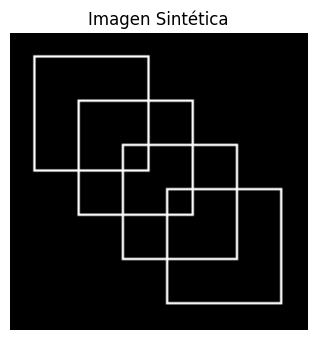

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def plot_image(image, title='', cmap='gray', alpha=1.0):
    plt.imshow(image, cmap=cmap, alpha=alpha)
    plt.title(title, size=12)
    plt.axis('off')

def create_synthetic_image(array_shape, num_rectangles, rect_height=50, rect_width=50, border_value=1, margin=10):
    """
    Crea una imagen sintética de ejemplo con rectángulos uniformemente distribuidos a lo largo de la diagonal.

    Parámetros:
        array_shape (tuple): Tamaño del array (altura, anchura).
        num_rectangles (int): Número de rectángulos a dibujar.
        rect_height (int): Altura de los rectángulos.
        rect_width (int): Anchura de los rectángulos.
        border_value (int): Valor de los píxeles de los bordes de los rectángulos.
        margin (int): Margen a dejar en los bordes del array.

    Retorna:
        np.array: Array con los bordes de los rectángulos dibujados.
    """
    array = np.zeros(array_shape, dtype=int)
    
    # Calcular el espacio disponible para distribuir los rectángulos
    available_height = array_shape[0] - 2 * margin - rect_height
    available_width = array_shape[1] - 2 * margin - rect_width
    
    step_x = available_height // (num_rectangles - 1) if num_rectangles > 1 else 0
    step_y = available_width // (num_rectangles - 1) if num_rectangles > 1 else 0
    
    for i in range(num_rectangles):
        start_x = margin + i * step_x
        start_y = margin + i * step_y
        
        # Dibujar el borde del rectángulo
        array[start_x, start_y:start_y + rect_width] = border_value  # Línea superior
        array[start_x + rect_height - 1, start_y:start_y + rect_width] = border_value  # Línea inferior
        array[start_x:start_x + rect_height, start_y] = border_value  # Línea izquierda
        array[start_x:start_x + rect_height, start_y + rect_width - 1] = border_value  # Línea derecha
    
    return array


# Crear una imagen sintética de ejemplo con bordes de rectángulos
im = create_synthetic_image(array_shape=(128, 128), num_rectangles=4)

# Mostrar la imagen
plt.figure(figsize=(10, 3.5)); plot_image(im, 'Imagen Sintética')
plt.tight_layout()
plt.show()

El fragmento de código anterior genera una imagen sintética con rectángulos distribuidos uniformemente a lo largo de la diagonal. Esta imagen servirá para ejemplificar la utilidad de la transformación de localización. Nuestro objetivo será detectar las esquinas inferiores izquierdas de los rectángulos presentes en la imagen.

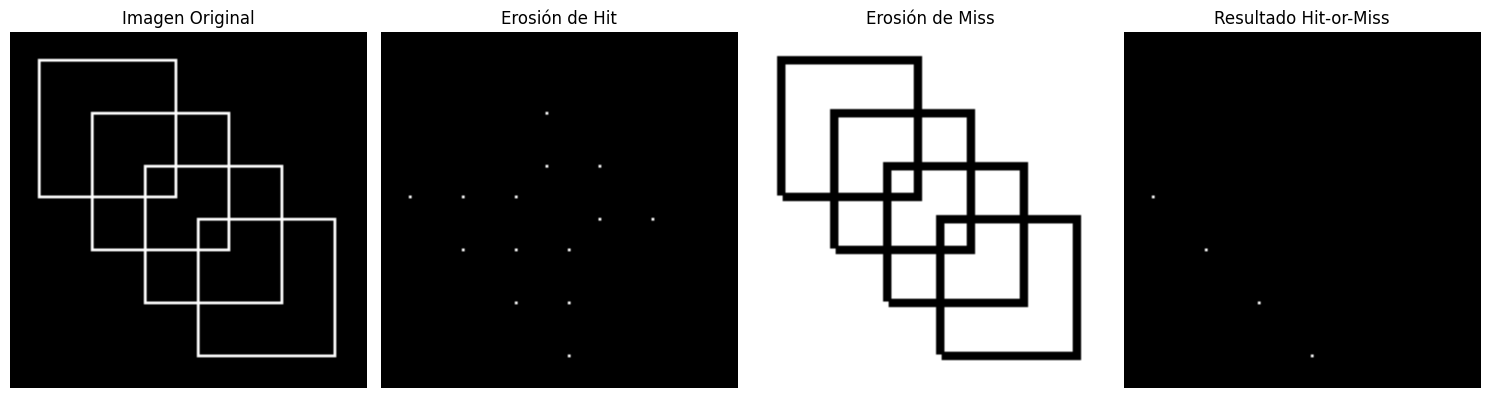

In [10]:
from skimage.morphology import binary_erosion

# Nos aseguramos que la imagen sea binaria
binary_image = (im > 0).astype(int)

# Definir los elementos estructurantes para detectar esquinas inferiores izquierdas
hit_structure = np.array([[0, 1, 0],
                          [0, 1, 1],
                          [0, 0, 0]], dtype=bool)

miss_structure = np.array([[1, 0, 0],
                           [1, 0, 0],
                           [1, 1, 1]], dtype=bool)

# Aplicar la transformada hit-or-miss
eroded_hit = binary_erosion(binary_image, hit_structure)
eroded_miss = binary_erosion(np.logical_not(binary_image), miss_structure)
hit_or_miss_result = eroded_hit & eroded_miss

# Mostrar las imágenes
plt.figure(figsize=(15, 5))
plt.subplot(1, 4, 1); plot_image(binary_image, 'Imagen Original')
plt.subplot(1, 4, 2); plot_image(eroded_hit, 'Erosión de Hit')
plt.subplot(1, 4, 3); plot_image(eroded_miss, 'Erosión de Miss')
plt.subplot(1, 4, 4); plot_image(hit_or_miss_result, 'Resultado Hit-or-Miss')
plt.tight_layout()
plt.show()

Para detectar las esquinas con la transformada *hit-or-miss*, definimos dos elementos estructurantes: *hit_structure*, que coincide con la configuración específica de la esquina, y *miss_structure*, que asegura que el área alrededor de la esquina esté libre de otras estructuras. Al aplicar la erosión con ambos elementos estructurantes y combinar los resultados, podemos localizar con precisión las esquinas inferiores izquierdas en la imagen.

### Transformación de Sombrero de Copa

La transformación de sombrero de copa ([top-hat](https://en.wikipedia.org/wiki/Top-hat_transform)) consta de dos pasos: primero, se identifican los objetos más pequeños de la imagen utilizando un elemento estructurante; segundo, se calcula la diferencia entre la imagen original y su apertura morfológica. Esto permite extraer pequeños elementos y detalles. Dependiendo de si los objetos detectados son los más brillantes o los más oscuros, la transformación de sombrero de copa se denomina blanca o negra. El siguiente fragmento de código muestra un ejemplo de uso utilizando el módulo de morfología de *scikit-image*.

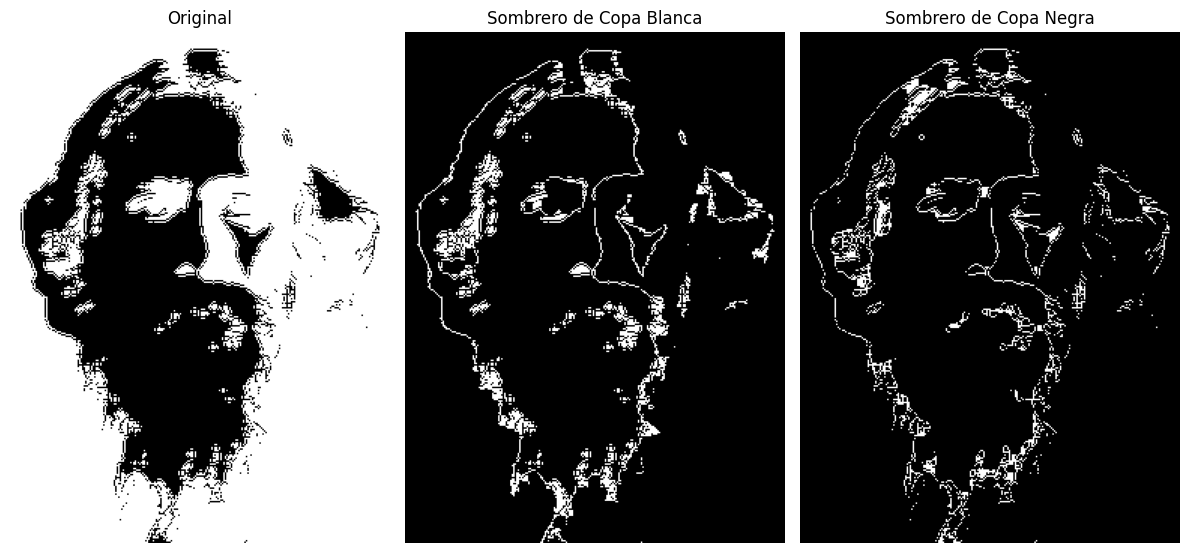

In [11]:
from skimage.io import imread
from skimage.morphology import white_tophat, black_tophat, footprint_rectangle

# Cargar y binarizar el canal alfa de la imagen
im = imread('images/tagore.png')[..., 3]
binary_image = (im > 0.5).astype(int)

# Aplicar transformaciones de sombrero de copa blanca y negra
im1 = white_tophat(binary_image, footprint_rectangle((5,5)))
im2 = black_tophat(binary_image, footprint_rectangle((5,5)))

# Mostrar las imágenes
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1); plot_image(binary_image, 'Original')
plt.subplot(1, 3, 2); plot_image(im1, 'Sombrero de Copa Blanca')
plt.subplot(1, 3, 3); plot_image(im2, 'Sombrero de Copa Negra')
plt.tight_layout()
plt.show()

Como puede observarse, la transformación de sombrero de copa blanca detecta las áreas brillantes más pequeñas que el elemento estructurante mientras que la versión negra resalta las zonas oscuras de tamaño reducido. Estas transformaciones permiten extraer y visualizar pequeños detalles y elementos específicos de la imagen original. En este ejemplo se aplican sobre imágenes binarias para mostrar su funcionamiento de manera sencilla. No obstante, su aplicación resulta especialmente útil en imágenes en escala de grises, donde, mediante las operaciones morfológicas sobre niveles de intensidad que se presentarán más adelante en esta práctica, pueden realzar variaciones locales de intensidad y facilitar la identificación de determinados detalles.

<div style="page-break-before: always;"></div>

___
<a class='anchor' id='adicionales10'></a>

## Herramientas Adicionales de Morfología

Además de las operaciones morfológicas básicas y de las transformaciones ya introducidas, existen herramientas adicionales que permiten profundizar en el análisis y el procesamiento de imágenes binarias. Técnicas como la esqueletización, el cálculo del envolvente convexo, la eliminación de objetos pequeños o la extracción de siluetas ofrecen formas más específicas de interpretar la estructura y la forma de los objetos presentes en la imagen, ampliando las posibilidades de tratamiento y facilitando su aplicación en tareas concretas.


### Esqueletización

En esta operación operación, cada componente conectado en una imagen binaria se reduce a un esqueleto de un solo píxel de ancho utilizando una técnica de [esqueletización morfológica](https://en.wikipedia.org/wiki/Morphological_skeleton). La esqueletización se logra mediante un proceso iterativo que aplica erosión junto con pruebas de conectividad para asegurar que se preserve la estructura y la topología de los objetos. El siguiente bloque de código muestra un ejemplo de uso en *scikit-image*.

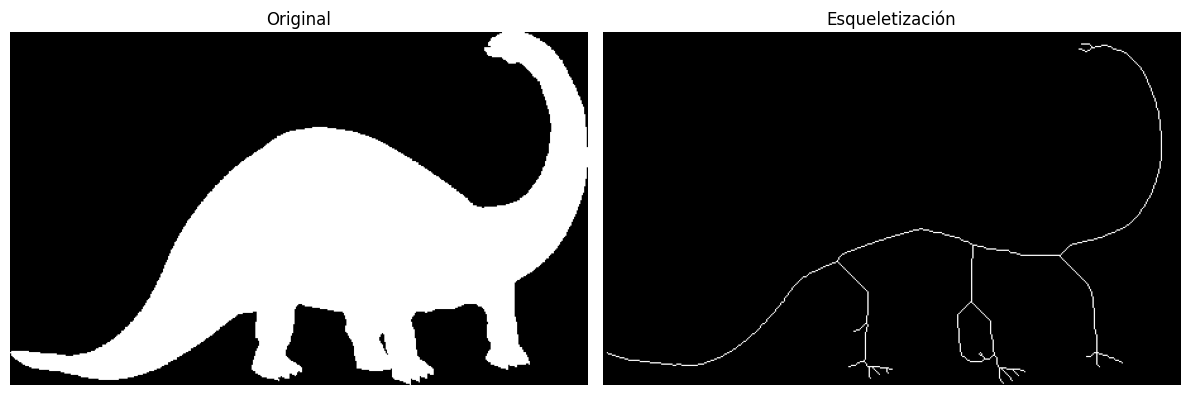

In [12]:
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.morphology import skeletonize

def plot_image(image, title='', cmap='gray', alpha=1.0):
    plt.imshow(image, cmap=cmap, alpha=alpha)
    plt.title(title, size=12)
    plt.axis('off')

# Cargar y binarizar la imagen
im = imread('images/dinasaur.png', as_gray=True)
binary_image = (im > 0.5).astype(int)

# Aplicar esqueletización
skeleton = skeletonize(binary_image)

# Mostrar la imagen original y la imagen esqueletizada
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1); plot_image(binary_image, 'Original')
plt.subplot(1, 2, 2); plot_image(skeleton, 'Esqueletización')
plt.tight_layout()
plt.show()

### Envolvente Convexa

La [envolvente convexa](https://en.wikipedia.org/wiki/Convex_hull) se define como el polígono convexo más pequeño que contiene todos los píxeles de primer plano (píxeles blancos) en una imagen binaria. Esta técnica es especialmente útil para simplificar las formas de los objetos y resaltar sus contornos principales. La función `convex_hull_image` de *scikit-image* calcula la envolvente convexa rellenando cualquier concavidad en el contorno del objeto, produciendo así una versión convexa del mismo. A continuación, se muestra un ejemplo de su aplicación.

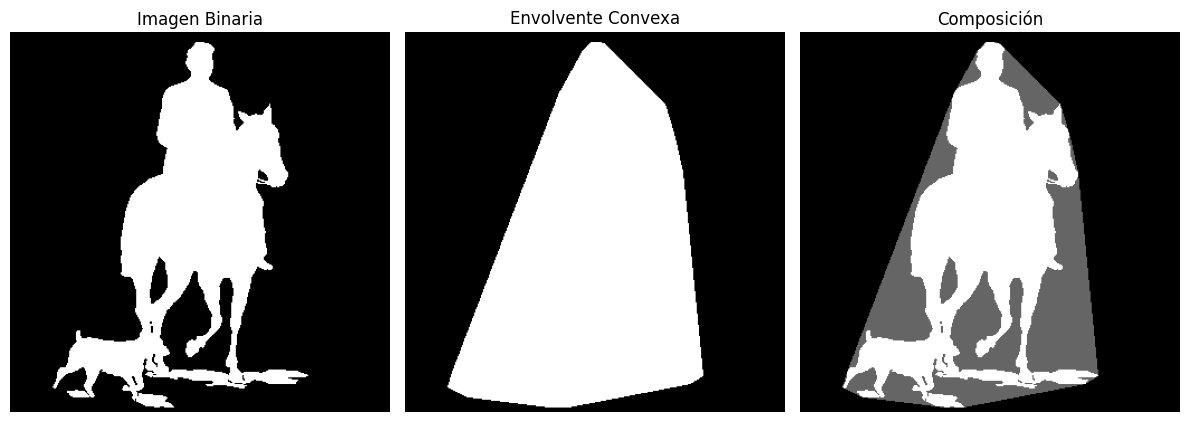

In [13]:
from skimage.color import rgb2gray
from skimage.morphology import convex_hull_image

# Cargar y binarizar la imagen
im = rgb2gray(imread('images/horse-dog.jpg'))
binary_image = (im >= 0.5).astype(int)

# Calcular su envolvente convexa
chull = convex_hull_image(binary_image)

# Mostrar el resultado
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1); plot_image(binary_image, 'Imagen Binaria')
plt.subplot(1, 3, 2); plot_image(chull, 'Envolvente Convexa')
plt.subplot(1, 3, 3); plot_image(binary_image, cmap='gray') 
plt.subplot(1, 3, 3); plot_image(chull, cmap='gray', alpha=0.4) 
plt.title('Composición'); plt.axis('off')
plt.tight_layout()
plt.show()

### Eliminación de Artefactos

Otra operación habitual para reducir el ruido y mejorar la segmentación en imágenes binarias consiste en la eliminación de pequeños objetos no deseados. Esto puede lograrse mediante la función `remove_small_objects` de *scikit-image*, que identifica los componentes conectados de la imagen y descarta aquellos cuyo tamaño no alcanza un umbral mínimo especificado. De este modo, permite limpiar artefactos que podrían interferir en el procesamiento posterior. A continuación se muestra un ejemplo de uso.

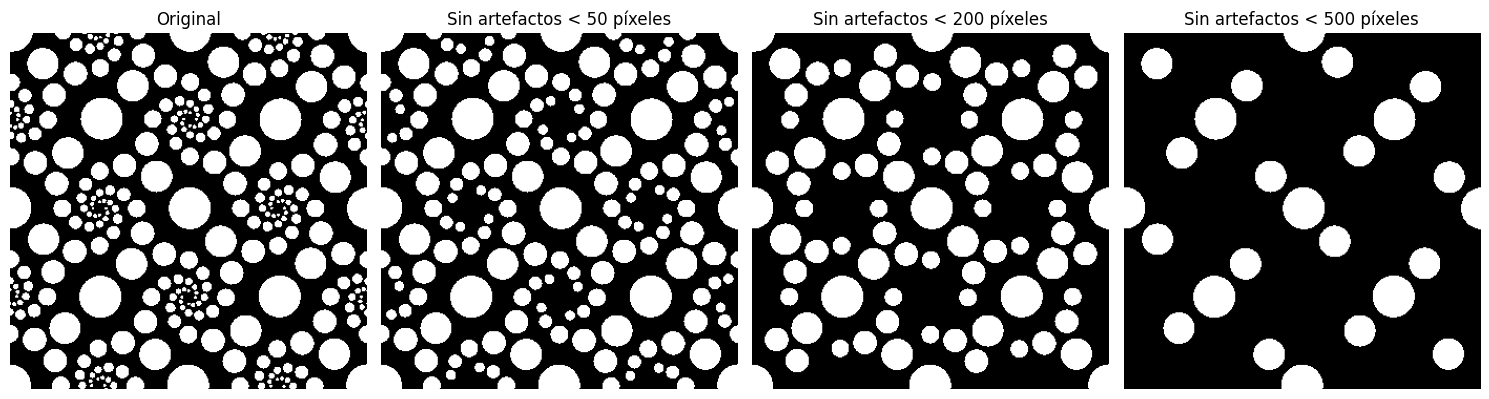

In [14]:
from skimage.morphology import remove_small_objects

# Cargar y binarizar la imagen
im = rgb2gray(imread('images/circles.jpg'))
binary_image = (im > 0.5).astype(bool)

# Configurar la figura
plt.figure(figsize=(15, 5))

# Mostrar la imagen original
plt.subplot(1, 4, 1)
plot_image(binary_image, 'Original')

# Aplicar remove_small_objects con diferentes tamaños y mostrar los resultados
for i, osz in enumerate([50, 200, 500], start=2):
    cleaned_image = remove_small_objects(binary_image, osz, connectivity=1) # connectivity=1 significa 4-conectividad para el cálculo de los componentes conectados
    plt.subplot(1, 4, i)
    plot_image(cleaned_image, f'Sin artefactos < {osz} píxeles')

# Mostrar las imágenes
plt.tight_layout()
plt.show()

De forma complementaria, otra función muy útil del módulo *scipy.ndimage* es `binary_fill_holes`, la cual permite rellenar los agujeros presentes en los objetos de una imagen binaria. En este caso, la estructura especificada no define directamente el tamaño de los agujeros a rellenar, sino que determina la conectividad utilizada para identificarlos. Si no se especifica una estructura (`structure=None`), se usa la conectividad por defecto y se rellenan todos los agujeros de la imagen. Al especificar una estructura, esta define qué píxeles se consideran conectados. Si los píxeles de un agujero no cumplen con el criterio de conectividad definido por la estructura, ese agujero no será detectado como tal y, por tanto, no se rellenará.

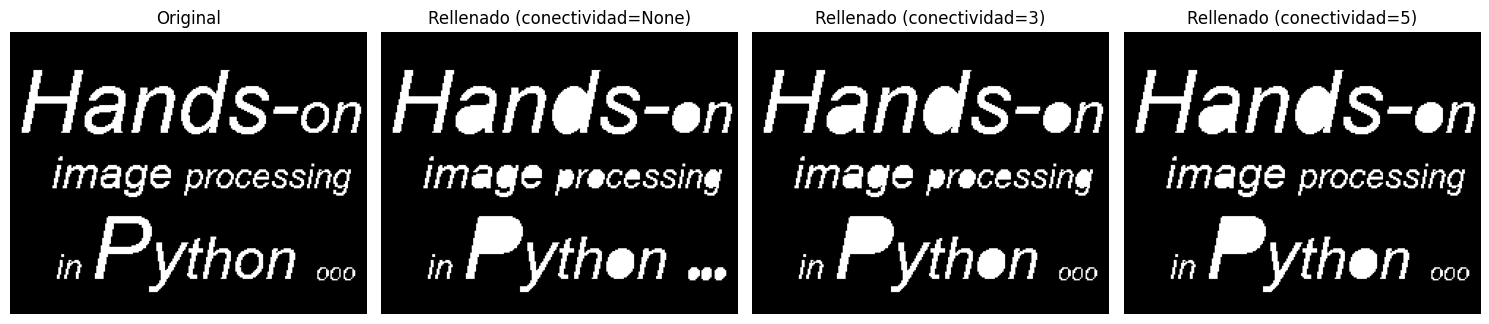

In [15]:
import numpy as np
from scipy.ndimage import binary_fill_holes

# Cargar y binarizar la imagen
im = imread('images/text.png', as_gray=True)
binary_image = (im > 0.5).astype(bool)

# Configurar la figura
plt.figure(figsize=(15, 5))

# Mostrar la imagen original
plt.subplot(1, 4, 1)
plot_image(binary_image, 'Original')

# Aplicar binary_fill_holes con diferentes conectividades y mostrar los resultados
for i, n in enumerate([None, 3, 5], start=2):
    connectivity = np.ones((n, n)) if n is not None else None
    cleaned_image = binary_fill_holes(binary_image, structure=connectivity)
    plt.subplot(1, 4, i)
    plot_image(cleaned_image, f'Rellenado (conectividad={n})')

# Mostrar las imágenes
plt.tight_layout()
plt.show()

### Extracción de Siluetas

Una forma sencilla de extraer las siluetas de los objetos de una imagen binaria consiste en utilizar la operación de erosión. Al restar la imagen erosionada de la imagen binaria original, se pueden resaltar los límites de los objetos. El siguiente bloque de código implementa esta estrategia.

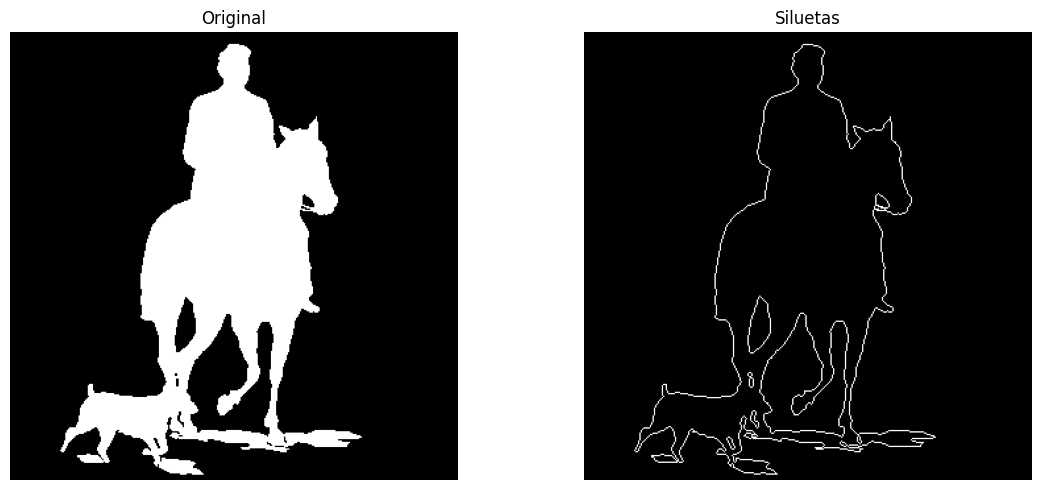

In [16]:
from skimage.morphology import binary_erosion

# Cargar y binarizar la imagen
im = rgb2gray(imread('images/horse-dog.jpg'))
binary_image = (im >= 0.5).astype(int)

# Extraer las siluetas
boundary = binary_image - binary_erosion(binary_image)

# Mostrar la imagen original y las siluetas
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1); plot_image(binary_image, 'Original')
plt.subplot(1, 2, 2); plot_image(boundary, 'Siluetas')
plt.tight_layout()
plt.show()

<div style="page-break-before: always;"></div>

___
<a class='anchor' id='geodesica10'></a>

## Morfológica Geodésica

Hasta ahora hemos trabajado con operaciones en las que un elemento estructurante actúa sobre la imagen de manera uniforme. Para abordar transformaciones más avanzadas es necesario introducir la morfología geodésica, un enfoque en el que la modificación de una imagen queda condicionada por otra. En este contexto intervienen dos imágenes: el **marcador**, que es la que se transforma, y la **máscara**, que establece los límites dentro de los cuales puede evolucionar el marcador. Esta relación permite definir operaciones más controladas y adaptadas al contenido de la imagen.

### Dilatación y Erosión Geodésica

La dilatación y la erosión geodésicas son las operaciones elementales de la morfología geodésica. En la **dilatación geodésica**, el marcador se dilata y posteriormente se combina con la máscara tomando el mínimo punto a punto, por lo que la máscara actúa como límite superior y el marcador únicamente puede crecer dentro de sus regiones. En la **erosión geodésica**, el marcador se erosiona y se combina con la máscara tomando el máximo punto a punto, de modo que la máscara actúa como límite inferior y el marcador solo puede contraerse sin sobrepasar ese umbral.

### Reconstrucción Geodésica

La reconstrucción geodésica se obtiene aplicando la dilatación o la erosión geodésica de forma repetida hasta que el marcador alcanza la estabilidad. En la **reconstrucción por dilatación**, el marcador se expande todo lo posible dentro de los límites marcados por la máscara, recuperando regiones conectadas a partir de semillas parciales. En la **reconstrucción por erosión**, el marcador se contrae de manera controlada siguiendo la restricción de la máscara, lo que permite depurar o simplificar estructuras sin modificar su extensión esencial. El resultado final es una imagen que refleja fielmente las zonas permitidas por la máscara, reconstruidas a partir del marcador inicial. El siguiente bloque de código ilustra el comportamiento de ambas operaciones.

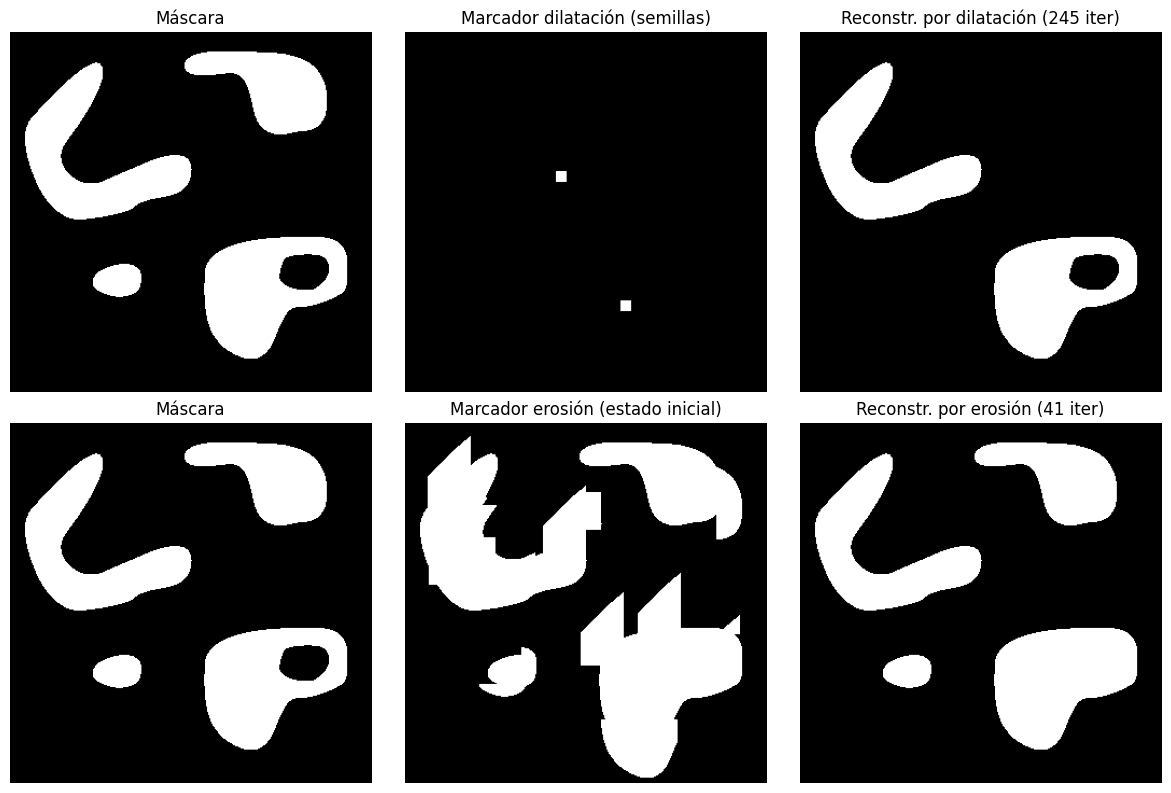

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.morphology import binary_dilation, binary_erosion

# Cargar y binarizar las imágenes
im1 = rgb2gray(imread("images/blobs-1.png")[..., :3])
im1 = (im1 >= 0.5).astype(int)
im2 = rgb2gray(imread("images/blobs-2.png")[..., :3])
im2 = (im2 >= 0.5).astype(int)

# Definir las máscaras y los marcadores
mask_dil = im1                                  # límite superior para la dilatación geodésica
marker_dil = np.zeros_like(mask_dil, dtype=int) # semillas para la dilatación geodésica
marker_dil[130:140, 140:150] = 1                
marker_dil[250:260, 200:210] = 1
mask_ero = im1      # límite inferior para la erosión geodésica
marker_ero = im2    # estado inicial para la erosión geodésica

# Elemento estructurante
se = np.array([[0, 1, 0],
               [1, 1, 1],
               [0, 1, 0]], dtype=int)

# Reconstrucción por dilatación geodésica (manual)
iteration_dil = 0
current = marker_dil.copy()
while True:
    iteration_dil += 1
    dilated = binary_dilation(current, se)
    next_step = np.minimum(dilated, mask_dil)
    if np.array_equal(next_step, current):
        break
    current = next_step
rec_dilation = current

# Reconstrucción por erosión geodésica (manual)
iteration_ero = 0
current = marker_ero.copy()
while True:
    iteration_ero += 1
    eroded = binary_erosion(current, se)
    next_step = np.maximum(eroded, mask_ero)
    if np.array_equal(next_step, current):
        break
    current = next_step
rec_erosion = current

# Visualización
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes[0, 0].imshow(mask_dil, cmap='gray'); axes[0, 0].set_title("Máscara"); axes[0, 0].axis('off')
axes[0, 1].imshow(marker_dil, cmap='gray'); axes[0, 1].set_title("Marcador dilatación (semillas)"); axes[0, 1].axis('off')
axes[0, 2].imshow(rec_dilation, cmap='gray'); axes[0, 2].set_title(f"Reconstr. por dilatación ({iteration_dil} iter)");axes[0, 2].axis('off')
axes[1, 0].imshow(mask_ero, cmap='gray'); axes[1, 0].set_title("Máscara"); axes[1, 0].axis('off')
axes[1, 1].imshow(marker_ero, cmap='gray'); axes[1, 1].set_title("Marcador erosión (estado inicial)"); axes[1, 1].axis('off')
axes[1, 2].imshow(rec_erosion, cmap='gray'); axes[1, 2].set_title(f"Reconstr. por erosión ({iteration_ero} iter)"); axes[1, 2].axis('off')
plt.tight_layout()
plt.show()

En el bloque de código anterior puede observarse cómo implementar estas operaciones paso a paso mediante iteraciones explícitas. Sin embargo, *scikit-image* incluye funciones que realizan la reconstrucción geodésica de forma automática. El siguiente código muestra que el resultado obtenido manualmente coincide con el generado por la función de la biblioteca.

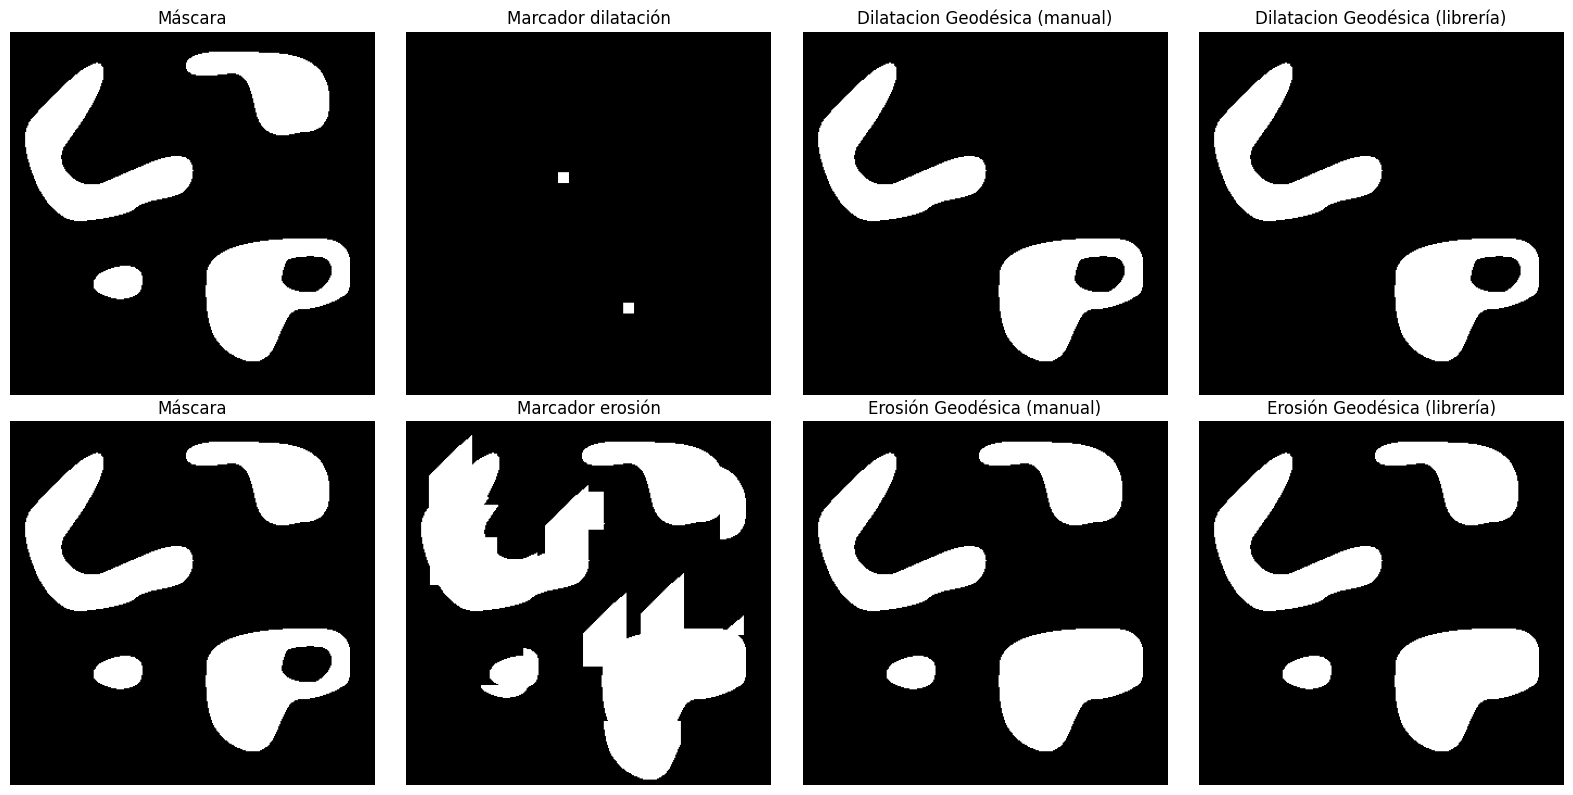

In [18]:
from skimage.morphology import reconstruction

# Reconstrucción por dilatación y erosión geodésica (librería)
rec_dilation_lib = reconstruction(marker_dil, mask_dil, method="dilation")
rec_erosion_lib = reconstruction(marker_ero, mask_ero, method="erosion")

# Visualización
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes[0,0].imshow(mask_dil, cmap='gray'); axes[0,0].set_title("Máscara"); axes[0,0].axis('off')
axes[0,1].imshow(marker_dil, cmap='gray'); axes[0,1].set_title("Marcador dilatación"); axes[0,1].axis('off')
axes[0,2].imshow(rec_dilation, cmap='gray'); axes[0,2].set_title("Dilatacion Geodésica (manual)"); axes[0,2].axis('off')
axes[0,3].imshow(rec_dilation_lib, cmap='gray'); axes[0,3].set_title("Dilatacion Geodésica (librería)"); axes[0,3].axis('off')
axes[1,0].imshow(mask_ero, cmap='gray'); axes[1,0].set_title("Máscara"); axes[1,0].axis('off')
axes[1,1].imshow(marker_ero, cmap='gray'); axes[1,1].set_title("Marcador erosión"); axes[1,1].axis('off')
axes[1,2].imshow(rec_erosion, cmap='gray'); axes[1,2].set_title("Erosión Geodésica (manual)"); axes[1,2].axis('off')
axes[1,3].imshow(rec_erosion_lib, cmap='gray'); axes[1,3].set_title("Erosión Geodésica (librería)"); axes[1,3].axis('off')
plt.tight_layout()
plt.show()

<div style="page-break-before: always;"></div>

___
<a class='anchor' id='gris10'></a>

## Morfología en Escala de Grises

A diferencia de las operaciones binarias, que trabajan con imágenes en blanco y negro, las operaciones [morfológicas en escala de grises](https://en.wikipedia.org/wiki/Mathematical_morphology#Grayscale_morphology) operan sobre imágenes con múltiples niveles de intensidad. Esto permite una manipulación más precisa y detallada, ya que las operaciones se basan en los valores máximos y mínimos de los píxeles dentro del área definida por el elemento estructurante. Entre las operaciones comunes en escala de grises se incluyen la dilatación, la erosión, la apertura y el cierre. A continuación, se muestra cómo aplicar estas operaciones en *scikit-image*.

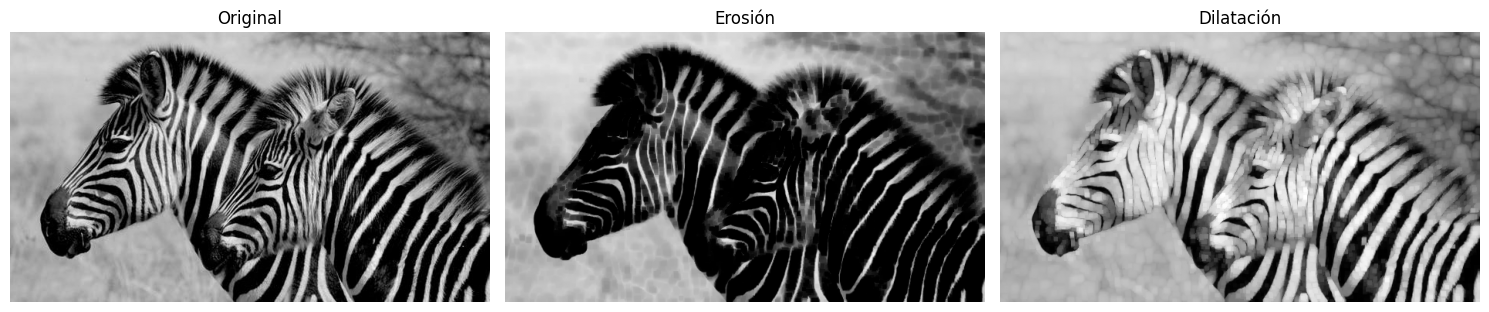

In [19]:
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.morphology import erosion, dilation, footprint_rectangle

# Cargar y procesar la imagen
im = imread('images/zebras.jpg')
im_gray = rgb2gray(im)

# Definir el elemento estructurante
struct_elem = footprint_rectangle((5, 5))

# Aplicar erosión
eroded = erosion(im_gray, struct_elem)

# Aplicar dilatación
dilated = dilation(im_gray, struct_elem)

# Mostrar las imágenes
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(im_gray, cmap='gray'); plt.title('Original', size=12); plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(eroded, cmap='gray'); plt.title('Erosión', size=12); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(dilated, cmap='gray'); plt.title('Dilatación', size=12); plt.axis('off')
plt.tight_layout()
plt.show()

En este ejemplo, se observa cómo la erosión y la dilatación afectan la estructura de la imagen. La erosión reduce el tamaño de los objetos en la imagen, mientras que la dilatación los expande, permitiendo resaltar diferentes características según la operación aplicada. Ahora, exploraremos las operaciones de apertura y cierre.

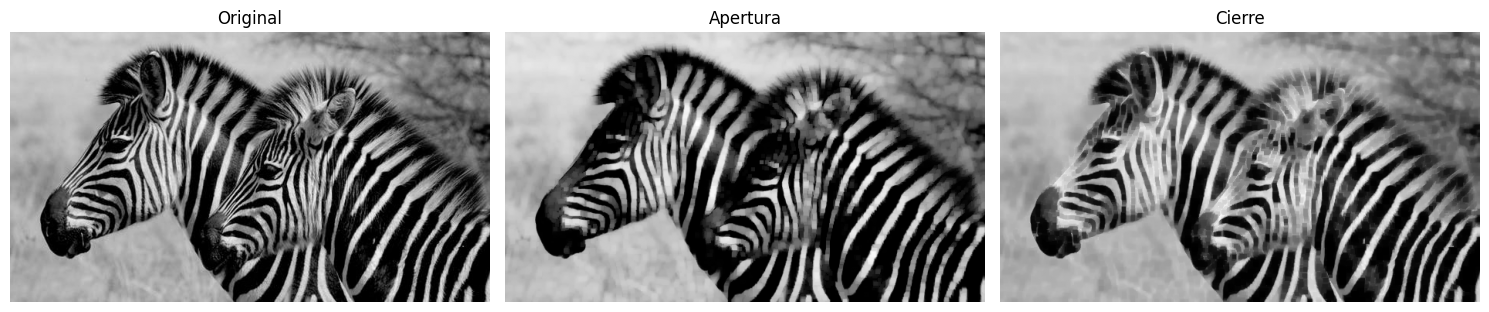

In [20]:
from skimage.morphology import opening, closing

# Aplicar apertura
opened = opening(im_gray, struct_elem)

# Aplicar cierre
closed = closing(im_gray, struct_elem)

# Mostrar las imágenes
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(im_gray, cmap='gray'); plt.title('Original', size=12); plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(opened, cmap='gray'); plt.title('Apertura', size=12); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(closed, cmap='gray'); plt.title('Cierre', size=12); plt.axis('off')
plt.tight_layout()
plt.show()

 Al comparar las imágenes resultantes, se puede observar cómo la apertura reduce el ruido y detalles menores, y el cierre mejora la continuidad y rellena espacios en las estructuras más grandes de la imagen.

<div style="page-break-before: always;"></div>

___
<a class='anchor' id='ejercicios10'></a>

## Ejercicios de práctica

### *Ejercicio 1. Detección de Células*

Desarrolla un programa en Python para detectar células concretas en una imagen de microscopio utilizando morfología matemática. Comienza cargando la imagen `images/cells.jpg` y conviértela a escala de grises. A continuación, umbraliza manualmente la imagen para identificar las regiones oscuras que corresponden a los núcleos oscuros de las células. Utilizando únicamente operaciones básicas de dilatación y erosión, implementa una operación de cierre para rellenar posibles huecos en los núcleos detectados y una operación de apertura para eliminar pequeños objetos y ruidos. Ajusta cuidadosamente todos los parámetros para asegurar una detección clara y precisa de los núcleos oscuros. Finalmente, muestra la imagen original, los núcleos detectados y la imagen con los núcleos resaltados.

<div style="text-align: center; margin-bottom: 20px;">
    <h3>Resultado esperado</h3>
</div>
<div style="display:flex; justify-content:center; align-items:center;">
    <img src="images/ej1_cells.jpg" style="width:70%; height:auto; margin-right: 50px;">
</div>
<br><br>

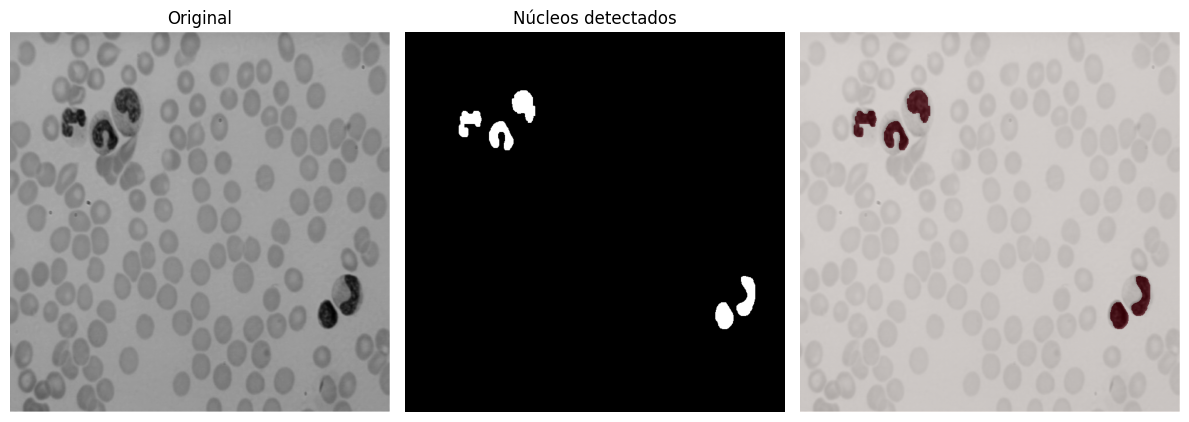

In [60]:
image = cv2.imread('images/cells.jpg', cv2.IMREAD_GRAYSCALE)

# Crear una imagen binaria con un umbral fijo de 0.5
_, binary_image = cv2.threshold(image, 90, 255, cv2.THRESH_BINARY)
im_umbralizada = 255 - binary_image

# Definir elemento estructurante
struct_elem = cv2.getStructuringElement(cv2.MORPH_RECT, (6, 6))

# Primero cierre
dilated_image = cv2.dilate(im_umbralizada, struct_elem)
eroded_image = cv2.erode(dilated_image, struct_elem)

# Ahora apertura
eroded_image2 = cv2.erode(eroded_image, struct_elem)
dilated_image2 = cv2.dilate(eroded_image2, struct_elem)



# Mostrar las imágenes
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1); plot_image(image, 'Original')
plt.subplot(1, 3, 2); plot_image(dilated_image2, 'Núcleos detectados')
plt.subplot(1, 3, 3); plot_image(image)
plt.subplot(1, 3, 3); plot_image(dilated_image2,cmap='Reds', alpha = 0.5)

plt.tight_layout()
plt.show()

### *Ejercicio 2. Restaurar Huella*

El procesamiento de imágenes es esencial para mejorar la calidad y precisión en el análisis de huellas dactilares, especialmente cuando éstas presentan ruido y otros artefactos que pueden dificultar su identificación. Desarrolla un programa en Python para restaurar la huella en `images/fingerprint.tif` utilizando técnicas de morfología matemática. Comienza cargando la imagen y convirtiéndola a formato binario mediante el método de umbralización de Otsu. A continuación, aplica la siguiente secuencia de operaciones morfológicas para mejorar la imagen: primero, una apertura para eliminar el ruido; segundo, una eliminación de pequeños objetos; y tercero, un cierre para suavizar la imagen y cerrar pequeños huecos. Ajusta cuidadosamente los parámetros de estas operaciones para asegurar una restauración lo más efectiva posible. Finalmente, muestra en pantalla la imagen original y todos los resultados obtenidos para mostrar la efectividad del proceso.

<div style="text-align: center; margin-bottom: 20px;">
    <h3>Resultado esperado</h3>
</div>
<div style="display:flex; justify-content:center; align-items:center;">
    <img src="images/ej2_fingerprint.jpg" style="width:80%; height:auto; margin-right: 50px;">
</div>
<br><br>

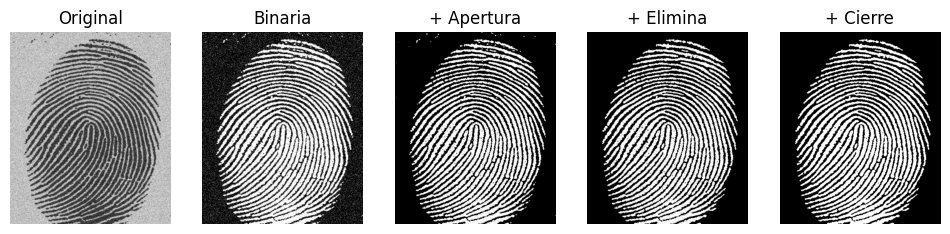

In [87]:
from skimage.filters import threshold_otsu

image = cv2.imread('images/fingerprint.tif', cv2.IMREAD_GRAYSCALE)

im_umbralizada = image < threshold_otsu(image)

# 1. Apertura
opened_image = binary_opening(im_umbralizada, disk(1))

# 2. Eliminación de artefactos
cleaned_image = remove_small_objects(opened_image, 100, connectivity=1)

# 3. Cierre
closed_image = binary_closing(cleaned_image, disk(1))


# Mostrar las imágenes
plt.figure(figsize=(12, 5))
plt.subplot(1, 5, 1); plot_image(image, 'Original')
plt.subplot(1, 5, 2); plot_image(im_umbralizada, 'Binaria')
plt.subplot(1, 5, 3); plot_image(opened_image, '+ Apertura')
plt.subplot(1, 5, 4); plot_image(cleaned_image, '+ Elimina')
plt.subplot(1, 5, 5); plot_image(closed_image, '+ Cierre')

### *Ejercicio 3. Análisis de Firma*

Desarrolla un programa en Python que permita analizar las características de una firma. Empieza cargando la imagen `images/signature.jpg` y segmenta la firma que contiene. Si es necesario, elimina pequeños objetos ruidosos para obtener una segmentación lo más precisa posible. A continuación, extrae dos características clave para el análisis de la firma: su esqueleto y su envolvente conexa. La esqueletización proporciona una representación simplificada de la firma que mantiene su estructura general, lo cual es fundamental para analizar la trazabilidad y la fluidez de las líneas. Por otro lado, identificar la envolvente conexa es esencial para evaluar la integridad y la continuidad de la firma. Termina tu programa mostrando en pantalla tanto la imagen original como la firma segmentada y las características clave extraídas.

<div style="text-align: center; margin-bottom: 20px;">
    <h3>Resultado esperado</h3>
</div>
<div style="display:flex; justify-content:center; align-items:center;">
    <img src="images/ej3_signature.jpg" style="width:80%; height:auto; margin-right: 50px;">
</div>
<br><br>

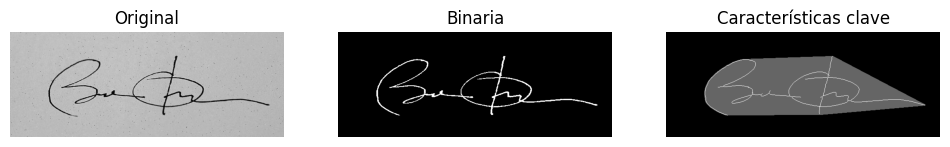

In [110]:
image = rgb2gray(imread('images/signature.jpg'))

# Sacamos la imagen binaria
binary_image = image < threshold_otsu(image)
cleaned_image = remove_small_objects(binary_image, 110, connectivity=1)

# Sacamos esqueletización
skeleton = skeletonize(cleaned_image)

# Sacamos envolvente convexa
chull = convex_hull_image(cleaned_image)

plt.figure(figsize=(12, 7))
plt.subplot(1, 3, 1); plot_image(image, 'Original')
plt.subplot(1, 3, 2); plot_image(cleaned_image, 'Binaria')
plt.subplot(1, 3, 3); plot_image(skeleton, 'Características clave')
plt.subplot(1, 3, 3); plot_image(chull, 'Características clave', alpha = 0.4)


### *Ejercicio 4. Realce Morfológico*

En este ejercicio, explorarás cómo realzar detalles en una imagen utilizando su gradiente morfológico. Este gradiente se obtiene a partir de la diferencia entre la dilatación y la erosión de una imagen en escala de grises, lo cual es efectivo para destacar bordes y estructuras. Comienza cargando la imagen `images/einstein.jpg` y calcula su gradiente morfológico usando un elemento estructurante cuadrado de tamaño 3. Luego, aplica una transformación de sombrero de copa blanca (white top-hat) para identificar los pequeños detalles. Finalmente, combina la imagen original con la transformación de sombrero de copa para realzar selectivamente los detalles en la imagen. Muestra las imágenes procesadas en pantalla para visualizar y comparar los efectos de cada paso del proceso.

<div style="text-align: center; margin-bottom: 20px;">
    <h3>Resultado esperado</h3>
</div>
<div style="display:flex; justify-content:center; align-items:center;">
    <img src="images/ej4_einstein.jpg" style="width:80%; height:auto; margin-right: 50px;">
</div>
<br><br>

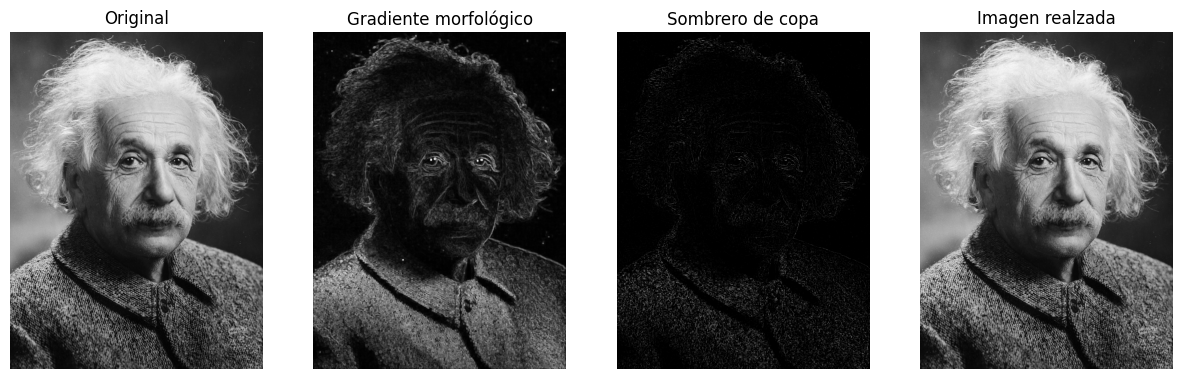

In [125]:
# Cargar y procesar la imagen
im = imread('images/einstein.jpg')


# Definir el elemento estructurante
struct_elem = footprint_rectangle((3, 3))

# Aplicar erosión
eroded = erosion(im, struct_elem)

# Aplicar dilatación
dilated = dilation(im, struct_elem)
gradiente = dilated - eroded

# Sombrero de copa blanca
sombrero = white_tophat(gradiente, footprint_rectangle((2,2)))

# Realce de imagen
suma = im + 1.2*sombrero
resultado = np.clip(suma, 0, 255)

plt.figure(figsize=(15, 10))
plt.subplot(1, 4, 1); plot_image(image, 'Original')
plt.subplot(1, 4, 2); plot_image(gradiente, 'Gradiente morfológico')
plt.subplot(1,4,3); plot_image(sombrero, 'Sombrero de copa')
plt.subplot(1,4,4); plot_image(resultado, 'Imagen realzada')
